In [1178]:
import polars as pl
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [1179]:
BASE_PATH: Path = Path.cwd()
RANDOM_SEED: float = 0

sns.set_theme(style="darkgrid", palette="dark")

In [1180]:
df_raw: pl.DataFrame = pl.read_csv(
    BASE_PATH / 'data' / 'raw' / 'raw_mock_sales_data.csv',
    schema_overrides = {
        'SaleDate': pl.String,
        'ProductID': pl.String,
        'ASP': pl.String,
        'QT': pl.String,
    }
)

In [1181]:
df_raw.head(5)

SaleDate,ProductID,ASP,QT
str,str,str,str
"""2024-02-11""","""P003""","""46.11""","""3.0"""
"""2025-04-20""","""P007""","""50.76""","""3.0"""
"""07/04/2025""","""P001""","""122.77""","""5.0"""
"""2020-02-14""","""P004""","""98.75""","""6.0"""
"""2022-06-28""","""P010""","""51.81""","""3.0"""


In [1182]:
df_raw.describe()

statistic,SaleDate,ProductID,ASP,QT
str,str,str,str,str
"""count""","""200174""","""200151""","""200175""","""200174"""
"""null_count""","""126""","""149""","""125""","""126"""
"""mean""",null,null,null,null
"""std""",null,null,null,null
"""min""","""01-03-2024""",""" P001 ""","""$10.00""","""-1.0"""
"""25%""",null,null,null,null
"""50%""",null,null,null,null
"""75%""",null,null,null,null
"""max""","""31/05/2026""","""product_1""","""9980.0""","""99.0"""


In [1183]:
def get_inconsistencies(df: pl.DataFrame, column: str, store: bool) -> pl.DataFrame | None:
    inconsistencies_df: pl.DataFrame = pl.DataFrame()

    if column == 'SaleDate':
        inconsistencies_df: pl.DataFrame = df.with_columns(
            pl.col(column).str.to_date(format='%Y-%m-%d', strict=False).is_null().alias('inconsistent'),
        ).filter(
            pl.col('inconsistent') == True
        )

    if column == 'ProductID':
        inconsistencies_df: pl.DataFrame = df.with_columns(
            ~pl.col(column).str.contains(r"^P\d{3}$").alias('inconsistent'),
        ).filter(
            pl.col('inconsistent') == True
        )

    if column in ['QT', 'ASP']:
        inconsistencies_df: pl.DataFrame = df.with_columns(
            (
                (pl.col(column).cast(pl.Float64, strict=False) <= 0) |
                (pl.col(column).cast(pl.Float64, strict=False).is_null())
            ).alias('inconsistent'),
        ).filter(
            pl.col('inconsistent') == True
        )

    inconsistencies_path: Path = BASE_PATH / 'exploratory_output' / 'inconsistencies'

    if len(inconsistencies_df) > 0 and store:
        inconsistencies_df.write_csv(
            inconsistencies_path / f'inconsistencies_{column}.csv',
            separator=';'
        )

        return inconsistencies_df
    return None

In [1184]:
for column in df_raw.columns:
    inconsistencies_df: pl.DataFrame = get_inconsistencies(df_raw, column, True)

    size: int | None = len(inconsistencies_df) if inconsistencies_df is not None else 0
    print(f'Column {column} inconsistencies: {size}')

Column SaleDate inconsistencies: 526
Column ProductID inconsistencies: 299
Column ASP inconsistencies: 575
Column QT inconsistencies: 576


In [1185]:
allowed_date_formats: list = [
    "%Y-%m-%d",    # 2022-01-15  (canonical)
    "%d/%m/%Y",    # 15/01/2022
    "%m-%d-%Y",    # 01-15-2022
    "%Y%m%d",      # 20220115
    "%d-%b-%Y",    # 15-Jan-2022
]

df_cleaned = (df_raw
    .filter(
        ~pl.col('ProductID').is_in(['UNKNOWN', '#REF!', 'N/A', 'P00O', 'null']),
        pl.col('ProductID') != 'P999',
        pl.col('ProductID').is_not_null(),
        pl.col('SaleDate').is_not_null(),
    )

    .with_columns(
        pl.coalesce([
            pl.col('SaleDate').str.to_date(format=date_format, strict=False)
            for date_format in allowed_date_formats
        ]).alias('SaleDate')
    )

    .with_columns(
        pl.col('ProductID').str.strip_chars().alias('ProductID')
    )

    .with_columns(
        pl.when(
            pl.col('ProductID').str.starts_with('p')
        ).then(
            pl.col('ProductID').str.replace('p', 'P')
        ).otherwise('ProductID').alias('ProductID')
    )

    .with_columns(
        pl.when(
            pl.col('ProductID').str.starts_with('Product')
        ).then(
            pl.col('ProductID').str.replace('Product', 'P')
        ).otherwise('ProductID').alias('ProductID')
    )

    .with_columns(
        pl.when(
            pl.col('ProductID') == 'P_1'
        ).then(
            pl.lit('P001')
        ).otherwise('ProductID').alias('ProductID')
    )

    .with_columns(
        pl.col('ASP').str.replace('$', '', literal=True).alias('ASP')
    )

    .with_columns(
        pl.when(
            pl.col('QT').cast(pl.Float64, strict=False) < 0
        ).then(
            - pl.col('QT').cast(pl.Float64, strict=False)
        ).otherwise('QT').alias('QT'),
        pl.when(
            pl.col('ASP').cast(pl.Float64, strict=False) < 0
        ).then(
            - pl.col('ASP').cast(pl.Float64, strict=False)
        ).otherwise('ASP').alias('ASP'),
    )

    .with_columns(
        pl.col('QT').cast(pl.Float64),
        pl.col('ASP').cast(pl.Float64)
    )
)


df_cleaned = (
    df_cleaned
    .sort(["ProductID", "SaleDate"])

    .with_columns(
        pl.col("ASP").forward_fill().over("ProductID"),
    )

    .with_columns(
        pl.col("ASP").backward_fill().over("ProductID"),
    )

    .with_columns(
        pl.col("QT").interpolate("linear").over("ProductID"),
    )

    .with_columns(
        pl.col("QT").fill_null(pl.col("QT").median().over("ProductID")),
    )
)

df_cleaned = df_cleaned.filter(
    pl.col('SaleDate') <= dt.datetime.today()
)

df_cleaned_test: pl.DataFrame = df_cleaned
for column in df_cleaned.columns:
    df_cleaned_test = df_cleaned_test.with_columns(
        pl.col(column).cast(pl.String)
    )

In [1186]:
for column in df_cleaned_test.columns:
    inconsistencies_df: pl.DataFrame = get_inconsistencies(df_cleaned_test, column, False)

    size: int = len(inconsistencies_df) if inconsistencies_df is not None else 0
    print(f'Column {column} inconsistencies: {size}')

Column SaleDate inconsistencies: 0
Column ProductID inconsistencies: 0
Column ASP inconsistencies: 0
Column QT inconsistencies: 0


In [1187]:
df_cleaned

SaleDate,ProductID,ASP,QT
date,str,f64,f64
2020-01-01,"""P001""",96.58,21.0
2020-01-01,"""P001""",97.77,13.0
2020-01-01,"""P001""",97.11,12.0
2020-01-01,"""P001""",97.23,12.0
2020-01-01,"""P001""",97.26,16.0
…,…,…,…
2026-06-17,"""P010""",47.72,14.0
2026-06-17,"""P010""",47.43,30.0
2026-06-17,"""P010""",47.68,19.0


In [1188]:
df_cleaned.describe()

statistic,SaleDate,ProductID,ASP,QT
str,str,str,f64,f64
"""count""","""199756""","""199756""",199756.0,199756.0
"""null_count""","""0""","""0""",0.0,0.0
"""mean""","""2023-04-30 17:32:35.097218""",null,69.080843,12.292229
"""std""",null,null,148.065141,125.783467
"""min""","""2020-01-01""","""P001""",0.09,0.0
"""25%""","""2021-09-27""",null,45.73,4.0
"""50%""","""2023-05-19""",null,61.64,8.0
"""75%""","""2024-12-10""",null,98.37,14.0
"""max""","""2026-06-17""","""P010""",12816.0,15500.0


In [1189]:
df_cleaned = df_cleaned.rename({
    'SaleDate': 'ds_full',
    'ProductID': 'SKU'
})

In [1190]:
df_featurized: pl.DataFrame = df_cleaned.with_columns(
    pl.col('ds_full').dt.year().alias('Y'),
    pl.col('ds_full').dt.month().alias('M'),
    pl.col('ds_full').dt.strftime("%Y/%m").alias('YearMonth')
).group_by([
    'SKU',
    'YearMonth',
    'Y',
    'M',
]).agg([
    pl.col('QT').sum().alias('QT'),
    pl.col('ASP').mean().alias('ASP'),
])

df_featurized = df_featurized.with_columns(
    pl.date(pl.col('Y'), pl.col('M'), 1).alias('ds')
)

In [1191]:
df_QT: pl.DataFrame = df_featurized.select(pl.exclude('ASP')).rename({'QT': 'y'})
df_ASP: pl.DataFrame = df_featurized.select(pl.exclude('QT')).rename({'ASP': 'y'})

In [1192]:
def line_plot(df: pl.DataFrame, x: str, y: str, hue: str | None = None) -> None:
    fig_in, ax_in = plt.subplots(figsize=(18, 6))
    sns.lineplot(data=df, x=x, y=y, hue=hue, ax=ax_in)

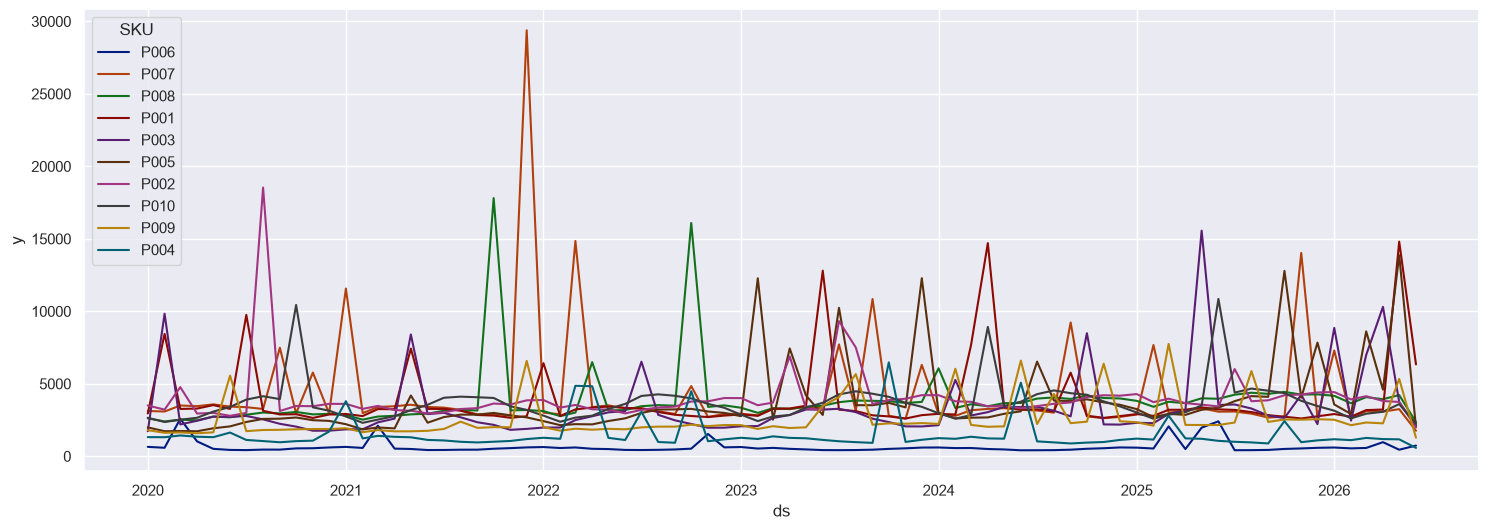

In [1193]:
line_plot(df_QT, x='ds', y='y', hue='SKU')

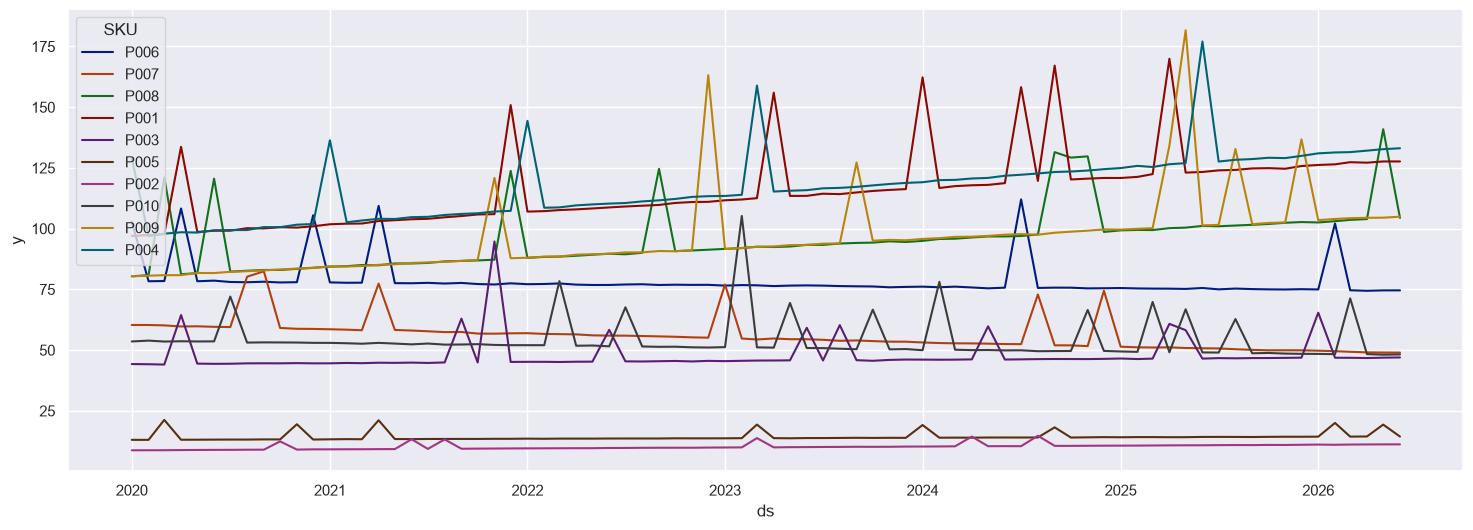

In [1194]:
line_plot(df_ASP, x='ds', y='y', hue='SKU')

In [1195]:
for target in ['QT', 'ASP']:
    window: int = 60

    rolling_mean = pl.col(target).rolling_mean(window_size=window).over('SKU')
    rolling_std = pl.col(target).rolling_std(window_size=window).over('SKU')

    df_cleaned = (
        df_cleaned
        .sort(['SKU', 'ds_full'])
        .with_columns(
            pl.col(target).rolling_mean(window_size=window).over('SKU').alias(f'{target}_rolling_mean'),
            pl.col(target).rolling_std(window_size=window).over('SKU').alias(f'{target}_rolling_std'),
        )

        .with_columns(
            (((pl.col(target) - pl.col(f'{target}_rolling_mean')) / pl.col(f'{target}_rolling_std')).abs() > 3).alias(f'{target}_outlier')
        )
    )

df_cleaned

ds_full,SKU,ASP,QT,QT_rolling_mean,QT_rolling_std,QT_outlier,ASP_rolling_mean,ASP_rolling_std,ASP_outlier
date,str,f64,f64,f64,f64,bool,f64,f64,bool
2020-01-01,"""P001""",96.58,21.0,null,null,null,null,null,null
2020-01-01,"""P001""",97.77,13.0,null,null,null,null,null,null
2020-01-01,"""P001""",97.11,12.0,null,null,null,null,null,null
2020-01-01,"""P001""",97.23,12.0,null,null,null,null,null,null
2020-01-01,"""P001""",97.26,16.0,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…
2026-06-17,"""P010""",47.72,14.0,11.25,6.358299,false,48.3135,0.521279,false
2026-06-17,"""P010""",47.43,30.0,11.55,6.803352,false,48.303667,0.532356,false
2026-06-17,"""P010""",47.68,19.0,11.7,6.867511,false,48.291,0.538068,false


In [1196]:
noise: np.ndarray = np.ones(len(df_QT_noiseless))
products: list[str] = df_QT_noiseless['ProductID'].unique().sort().to_list()

for i, product in enumerate(products):
    mask: np.ndarray[bool] = (df_QT_noiseless["ProductID"] == product).to_numpy()
    mask_size: int = mask.sum()
    noise[mask]: Iterator[float] = np.random.default_rng(RANDOM_SEED + i).normal(1.0, 0.05, mask_size)

df_QT: pl.DataFrame = df_QT_noiseless.with_columns(
    (pl.col("y") * pl.Series("noise", noise)).round(2).alias("y")
)

ColumnNotFoundError: "ProductID" not found

In [ ]:
line_plot(df_QT, x='ds', y='y', hue='ProductID')

In [ ]:
df_QT: pd.DataFrame = df_QT.to_pandas()
df_QT['ds'] = pd.to_datetime(df_QT['ds'])

In [ ]:
def components_plot(df: pd.DataFrame, product: str) -> None:
    components_colors: dict[str, str] = {
        "Observed": "grey",
        "Trend": "blue",
        "Seasonality": "red",
        "Residual": "yellow",
    }

    fig, axes = plt.subplots(
        figsize = (22, 4),
        nrows = 1,
        ncols = 4,
    )

    fig.suptitle(f"STL Decomposition for QT. Product {product}", fontsize=16, fontweight="bold")

    product_series: pd.Series = (
        df[df["ProductID"] == product]
        .set_index("ds")["y"]
        .asfreq("MS")
    )
    stl: STL = STL(product_series, period=12, robust=True)
    result: DecomposeResult = stl.fit()

    components: dict[str, pd.Series] = {
        'Observed': product_series,
        'Trend': result.trend,
        'Seasonality': result.seasonal,
        'Residual': result.resid
    }

    for col_idx, (component_name, component_series) in enumerate(components.items()):
        axes[col_idx].set_title(
            component_name,
            fontsize = 14,
            fontweight = 'bold',
        )
        ax = axes[col_idx]

        if component_name in ('Seasonality', 'Residual'):
            ax.axhline(0, color='grey', linewidth=1, linestyle='--', alpha=0.6)

        if component_name == 'Residual':
            sns.scatterplot(
                x = component_series.index,
                y = component_series.values,
                ax = ax,
                color = components_colors[component_name],
            )
        else:
            sns.lineplot(
                x = component_series.index,
                y = component_series.values,
                ax = ax,
                color = components_colors[component_name],
            )

        ax.tick_params(axis="y", labelsize=9, left=True, labelleft=True)

        for spine in ax.spines.values():
                spine.set_linewidth(0.8)
                spine.set_color("grey")

    plt.tight_layout()
    plt.show()
    display(HTML("<div style='margin-bottom: 40px'></div>"))

In [ ]:
df_QT_P001: pd.DataFrame = df_QT[df_QT['ProductID'] == 'P001']
components_plot(df_QT_P001, 'P001')

In [ ]:
def seasonal_plot(df: pd.DataFrame, product: str) -> None:
    fig, axes = plt.subplots(figsize=(22, 4))
    fig.suptitle(f"Seasonal plot for QT. Product {product}", fontsize=16, fontweight="bold")

    sns.lineplot(
        data = df,
        x = 'month',
        y = 'y',
        hue = 'year',
        marker = 'o',
        legend = False
    )

    plt.tight_layout()

In [ ]:
def month_boxplot(df: pd.DataFrame, product: str) -> None:
    fig, axes = plt.subplots(figsize=(22, 4))
    fig.suptitle(f"Month boxplot for QT. Product {product}", fontsize=16, fontweight="bold")

    sns.boxplot(
        data = df,
        x = 'month',
        y = 'y'
    )

    plt.tight_layout()

In [ ]:
df_QT_P001_seasonal: pd.DataFrame = df_QT_P001.copy()
df_QT_P001_seasonal['month'] = df_QT_P001_seasonal['ds'].dt.month
df_QT_P001_seasonal['year'] = df_QT_P001_seasonal['ds'].dt.year

df_P001_QT_seasonal: pd.DataFrame = df_QT_P001_seasonal[df_QT_P001_seasonal['ProductID'] == 'P001']
seasonal_plot(df_QT_P001_seasonal, 'P001')

In [ ]:
month_boxplot(df_QT_P001_seasonal, 'P001')

In [ ]:
prophet_anomaly_detector: Prophet = Prophet(interval_width=0.99)
prophet_anomaly_detector.fit(df_QT_P001[['ds', 'y']])
outlier_detection_QT_P001: pd.DataFrame = prophet_anomaly_detector.predict(df_QT_P001)

df_QT_P001 = df_QT_P001.merge(
    outlier_detection_QT_P001[['ds', 'yhat_upper', 'yhat_lower']],
    on='ds',
    how='left'
)

df_QT_P001['outlier']: pd.Series = np.where(
    (df_QT_P001['yhat_lower'] > df_QT_P001['y']) |
    (df_QT_P001['yhat_upper'] < df_QT_P001['y']),
    True, False
)

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(
    x = df_QT_P001['ds'],
    y = df_QT_P001['y'],
    ax = ax,
    linewidth = 1,
    label = 'Actual'
)

sns.scatterplot(
    x = df_QT_P001[df_QT_P001['outlier']]['ds'],
    y = df_QT_P001.loc[df_QT_P001['outlier'], 'y'],
    ax = ax,
    color = 'red',
    s = 60,
    zorder = 5,
    label = 'Outlier'
)

ax.set_title('QT detected outliers for Product P001')
plt.tight_layout()
plt.show()

In [ ]:
df_QT_P001[df_QT_P001['outlier'] == True]

In [ ]:
df_QT_P001_clean: pd.DataFrame = df_QT_P001.copy()
df_QT_P001_clean.loc[df_QT_P001_clean['outlier'], 'y'] = np.nan

In [ ]:
line_plot(df_QT_P001_clean, x='ds', y='y')

In [ ]:
forecast_model: ForecastModel = ForecastModel(
    material = 'P001',
    target = 'QT',
    model_name = 'mock_data_model'
)

hyperparameters_QT_P001: dict = forecast_model.hyperparameterize(
    df_QT_P001_clean,
    n_trials = 10,
    store = False
)